In [4]:
import numpy as np
import pennylane as qml
import hybridlane as hqml

# Create the bosonic qiskit simulator with custom Fock truncation
dev = qml.device("bosonicqiskit.hybrid", max_fock_level=8)

# Define a hybrid circuit with familiar Pennylane syntax
@qml.qnode(dev)
def circuit(n):
    # Python control flow allowed
    for j in range(n):
        # You can use existing Pennylane gates.
        qml.X(0) # wire `0` inferred to be a qubit

        # Or use the hybrid CV-DV gates in Hybridlane
        # (!) Qubits come before qumodes, allowing m0 to be inferred as a qumode
        hqml.JaynesCummings(np.pi / (2 * np.sqrt(j + 1)), np.pi / 2, [0, "m0"])

    # Freely mix qubit and qumode observables
    # (!) We use `hqml` for measurements and for CV observables
    return hqml.expval(hqml.NumberOperator("m0") @ qml.Z(0))

# Execute the circuit
expval = circuit(5)
# array(5.)

# Or analyze its structure
import hybridlane.sa as sa
res = sa.analyze(circuit._tape)
res.schemas[0].__dict__

{'_wire_map': {'m0': <ComputationalBasis.Discrete: 1>,
  0: <ComputationalBasis.Discrete: 1>}}

In [5]:
res.qumodes

Wires(['m0'])

In [6]:
hqml.to_openqasm(circuit, precision=5)(5)

'\nOPENQASM 3.0;\ninclude "stdgates.inc";\n\nconst int homodyne_precision_bits = 32;\nconst int fock_readout_precision_bits = 32;\ninclude "cvstdgates.inc";\n\n\nqubit[1] q;\nqumode[1] m;\n\ndef state_prep() {\n    reset q;\n    reset m;\n    x q[0];\n    cv_jc(1.57080, 1.57080) q[0], m[0];\n    x q[0];\n    cv_jc(1.11072, 1.57080) q[0], m[0];\n    x q[0];\n    cv_jc(0.90690, 1.57080) q[0], m[0];\n    x q[0];\n    cv_jc(0.78540, 1.57080) q[0], m[0];\n    x q[0];\n    cv_jc(0.70248, 1.57080) q[0], m[0];\n}\n\nstate_prep();\nbit[1] c0;\nc0[0] = measure q[0];\nuint[fock_readout_precision_bits] c1 = measure_n m[0];\n\n'

In [ ]:
import numpy as np
from dataclasses import dataclass
from typing import Callable, Dict, Optional, Tuple

# CV-DV Trotterization via hybrid swap network inspired by arXiv:2502.16029
@dataclass
class HybridInteraction:
    gate: Callable
    param_fn: Callable[[float], Tuple]
    kwargs: Optional[Dict] = None

    def apply(self, dt, wires):
        params = self.param_fn(dt)
        kw = {} if self.kwargs is None else dict(self.kwargs)
        self.gate(*params, wires=wires, **kw)

def jaynes_cummings_interaction(coupling, phase=np.pi / 2):
    return HybridInteraction(
        gate=hqml.JaynesCummings,
        param_fn=lambda dt, g=coupling, phi=phase: (g * dt, phi),
    )

def _resolve_mode_swap_gate(custom_gate):
    if custom_gate is not None:
        return custom_gate
    for attr in ("CVSWAP", "CVSwap", "ModeSwap"):
        if hasattr(hqml, attr):
            return getattr(hqml, attr)
    return None

def _mode_swap_layer(logical_modes, physical_modes, swap_gate):
    if len(physical_modes) < 2:
        return logical_modes
    for idx in range(len(physical_modes) - 1):
        wires = [physical_modes[idx], physical_modes[idx + 1]]
        if swap_gate is not None:
            swap_gate(wires=wires)
        else:
            qml.Beamsplitter(np.pi / 2, 0.0, wires=wires)
            qml.PhaseShift(np.pi, wires=wires[0])
            qml.PhaseShift(np.pi, wires=wires[1])
    return logical_modes[1:] + logical_modes[:1]

def _qubit_swap_layer(logical_qubits, physical_qubits):
    if len(physical_qubits) < 2:
        return logical_qubits
    for idx in range(len(physical_qubits) - 1):
        qml.SWAP(wires=[physical_qubits[idx], physical_qubits[idx + 1]])
    return logical_qubits[1:] + logical_qubits[:1]

def apply_cv_dv_swap_network_trotter(
    total_time,
    steps,
    qubit_wires,
    mode_wires,
    interactions,
    qubit_labels=None,
    mode_labels=None,
    swap_qubits=False,
    mode_swap=None,
):
    dt = total_time / steps
    physical_qubits = list(qubit_wires)
    physical_modes = list(mode_wires)
    logical_qubits = list(qubit_labels or qubit_wires)
    logical_modes = list(mode_labels or mode_wires)
    swap_gate = _resolve_mode_swap_gate(mode_swap)
    layers = len(physical_modes)
    for _ in range(steps):
        for _ in range(layers):
            max_pairs = min(len(physical_qubits), len(physical_modes))
            for idx in range(max_pairs):
                q_label = logical_qubits[idx]
                m_label = logical_modes[idx]
                term = interactions.get((q_label, m_label))
                if term is None:
                    continue
                term.apply(dt, [physical_qubits[idx], physical_modes[idx]])
            if swap_qubits:
                logical_qubits = _qubit_swap_layer(logical_qubits, physical_qubits)
            logical_modes = _mode_swap_layer(logical_modes, physical_modes, swap_gate)

# Example: two qubits coupled to two qumodes with all-to-all Jaynes-Cummings interactions
qubit_wires = [0, 1]
mode_wires = ["m0", "m1"]
qubit_labels = qubit_wires
mode_labels = mode_wires

couplings = np.array([[0.8, 0.4],
                      [0.3, 0.6]])

interactions = {
    (q_label, m_label): jaynes_cummings_interaction(couplings[q_idx, m_idx])
    for q_idx, q_label in enumerate(qubit_labels)
    for m_idx, m_label in enumerate(mode_labels)
}

@qml.qnode(dev)
def swap_network_trotter(time, steps):
    apply_cv_dv_swap_network_trotter(
        total_time=time,
        steps=steps,
        qubit_wires=qubit_wires,
        mode_wires=mode_wires,
        interactions=interactions,
        qubit_labels=qubit_labels,
        mode_labels=mode_labels,
    )
    return hqml.expval(hqml.NumberOperator("m0") + hqml.NumberOperator("m1"))

expval_swap_network = swap_network_trotter(time=0.6, steps=3)
expval_swap_network


In [9]:
# 2-local gadget example following the mediated CV-DV construction in arXiv:2502.16029
# Data qubits couple sequentially to a shared bus mode; only qubit-mode interactions appear at the gate level.
def apply_two_local_gadget(
    total_time,
    steps,
    data_qubits,
    bus_mode,
    couplings,
):
    dt = total_time / steps
    ordering = list(data_qubits)
    interactions = {
        q_wire: jaynes_cummings_interaction(couplings[q_wire])
        for q_wire in ordering
    }
    for _ in range(steps):
        for q_wire in ordering:
            interactions[q_wire].apply(0.5 * dt, [q_wire, bus_mode])
        for q_wire in reversed(ordering):
            interactions[q_wire].apply(0.5 * dt, [q_wire, bus_mode])

@qml.qnode(dev)
def two_local_gadget_demo(time, steps, theta):
    # Prepare a single excitation shared between the qubit register and the bus
    qml.X(0)
    qml.RY(theta, wires=1)
    apply_two_local_gadget(
        total_time=time,
        steps=steps,
        data_qubits=[0, 1],
        bus_mode="m0",
        couplings={0: 0.75, 1: 0.45},
    )
    return (
        qml.expval(qml.prod(qml.PauliZ(0), qml.PauliZ(1))),
        hqml.expval(hqml.NumberOperator("m0")),
    )

zz_corr, bus_population = two_local_gadget_demo(time=0.9, steps=4, theta=0.8)
zz_corr, bus_population


(array(-0.18091292), array(0.40018649))

(<Figure size 1500x500 with 1 Axes>, <Axes: >)

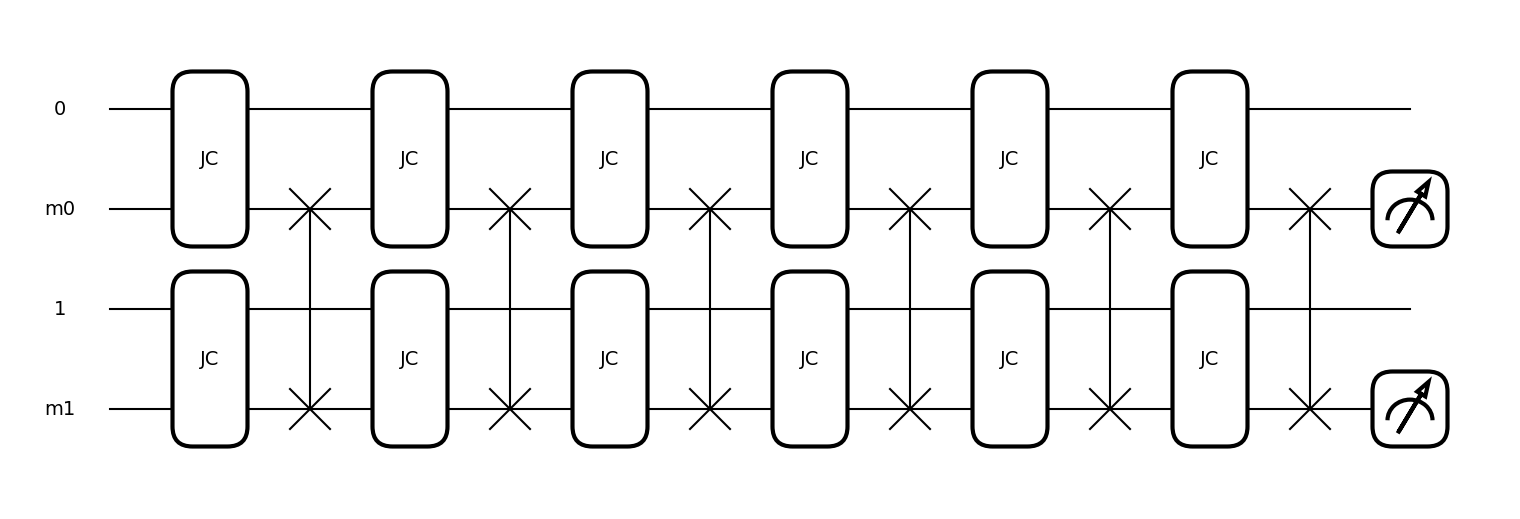

In [12]:
qml.draw_mpl(swap_network_trotter)(time=0.6, steps=3)



In [ ]:
 qml.draw_mpl()